# PM2.5 City-wise Extreme Event Ranking
This notebook compares extreme PM2.5 pollution events across cities using
daily SARIMA forecast outputs. It ranks cities by event frequency, severity,
and forecast difficulty during extreme conditions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("../results/PM25_SARIMA_forecast_daily.csv", parse_dates=["Date"])
df.head()

,Date,City,Actual_PM25,Forecast_PM25
0,2023-01-01,Montréal,3.791667,7.617046
1,2023-01-02,Montréal,8.791667,7.076527
2,2023-01-03,Montréal,10.166667,7.060252
3,2023-01-04,Montréal,5.208333,6.638644
4,2023-01-05,Montréal,7.875000,7.349447


In [6]:
threshold = df["Actual_PM25"].quantile(0.95)
print("Overall extreme threshold:", round(threshold, 2))

df["Extreme"] = df["Actual_PM25"] > threshold
df["Abs_Error"] = (df["Actual_PM25"] - df["Forecast_PM25"]).abs()
df.head()

Overall extreme threshold: 29.98


,Date,City,Actual_PM25,Forecast_PM25,Extreme,Abs_Error
0,2023-01-01,Montréal,3.791667,7.617046,False,3.825379
1,2023-01-02,Montréal,8.791667,7.076527,False,1.715140
2,2023-01-03,Montréal,10.166667,7.060252,False,3.106415
3,2023-01-04,Montréal,5.208333,6.638644,False,1.430311
4,2023-01-05,Montréal,7.875000,7.349447,False,0.525553


In [8]:
city_summary = df.groupby("City").agg(
    Total_Days=("Date", "count"),
    Extreme_Days=("Extreme", "sum"),
    Avg_PM25=("Actual_PM25", "mean"),
    Max_PM25=("Actual_PM25", "max"),
    Avg_Abs_Error=("Abs_Error", "mean")
).reset_index()

city_summary["Extreme_%"] = round(city_summary["Extreme_Days"] / city_summary["Total_Days"] * 100, 2)
city_summary = city_summary.sort_values("Extreme_Days", ascending=False)
city_summary

,City,Total_Days,Extreme_Days,Avg_PM25,Max_PM25,Avg_Abs_Error,Extreme_%
2,Fort Mckay,365,80,24.699185,354.625000,20.149493,21.92
1,Edmonton,365,49,16.989758,322.416667,12.541748,13.42
0,Calgary,365,20,12.231500,148.916667,7.790626,5.48
3,Hamilton,365,9,10.155349,85.458333,4.846444,2.47
8,Sarnia,365,8,9.492942,116.875000,4.936079,2.19
9,Toronto,365,7,8.931692,81.500000,4.531657,1.92
5,Montréal,365,5,8.040112,121.375000,4.125698,1.37
6,Quebec,365,3,8.436611,97.208333,4.311742,0.82
4,Kitimat,365,2,3.985107,44.625000,2.309401,0.55
7,Saint John,365,0,5.463354,19.875000,2.106374,0.00


In [10]:
extreme_df = df[df["Extreme"]].copy()
extreme_city_summary = extreme_df.groupby("City").agg(
    Extreme_Days=("Date", "count"),
    Avg_Extreme_PM25=("Actual_PM25", "mean"),
    Max_Extreme_PM25=("Actual_PM25", "max"),
    Extreme_Day_MAE=("Abs_Error", "mean")
).reset_index()

extreme_city_summary = extreme_city_summary.sort_values("Avg_Extreme_PM25", ascending=False)
extreme_city_summary

,City,Extreme_Days,Avg_Extreme_PM25,Max_Extreme_PM25,Extreme_Day_MAE
2,Fort Mckay,80,81.983620,354.625000,76.002617
0,Calgary,20,69.993841,148.916667,60.153664
1,Edmonton,49,68.781167,322.416667,58.017384
7,Sarnia,8,61.864583,116.875000,54.120777
5,Montréal,5,54.708333,121.375000,47.638535
6,Quebec,3,53.652778,97.208333,45.449115
3,Hamilton,9,50.967593,85.458333,42.701443
8,Toronto,7,50.589286,81.500000,42.527935
4,Kitimat,2,39.895833,44.625000,35.255781


In [14]:
final_ranking = pd.merge(
    city_summary,
    extreme_city_summary,
    on="City",
    how="left",
    suffixes=("_all", "_extreme")
)

final_ranking = final_ranking.sort_values(
    ["Extreme_Days_extreme", "Avg_Extreme_PM25"],
    ascending=[False, False]
)
final_ranking

,City,Total_Days,Extreme_Days_all,Avg_PM25,Max_PM25,Avg_Abs_Error,Extreme_%,Extreme_Days_extreme,Avg_Extreme_PM25,Max_Extreme_PM25,Extreme_Day_MAE
0,Fort Mckay,365,80,24.699185,354.625000,20.149493,21.92,80.0,81.983620,354.625000,76.002617
1,Edmonton,365,49,16.989758,322.416667,12.541748,13.42,49.0,68.781167,322.416667,58.017384
2,Calgary,365,20,12.231500,148.916667,7.790626,5.48,20.0,69.993841,148.916667,60.153664
3,Hamilton,365,9,10.155349,85.458333,4.846444,2.47,9.0,50.967593,85.458333,42.701443
4,Sarnia,365,8,9.492942,116.875000,4.936079,2.19,8.0,61.864583,116.875000,54.120777
5,Toronto,365,7,8.931692,81.500000,4.531657,1.92,7.0,50.589286,81.500000,42.527935
6,Montréal,365,5,8.040112,121.375000,4.125698,1.37,5.0,54.708333,121.375000,47.638535
7,Quebec,365,3,8.436611,97.208333,4.311742,0.82,3.0,53.652778,97.208333,45.449115
8,Kitimat,365,2,3.985107,44.625000,2.309401,0.55,2.0,39.895833,44.625000,35.255781
9,Saint John,365,0,5.463354,19.875000,2.106374,0.00,NaN,NaN,NaN,NaN


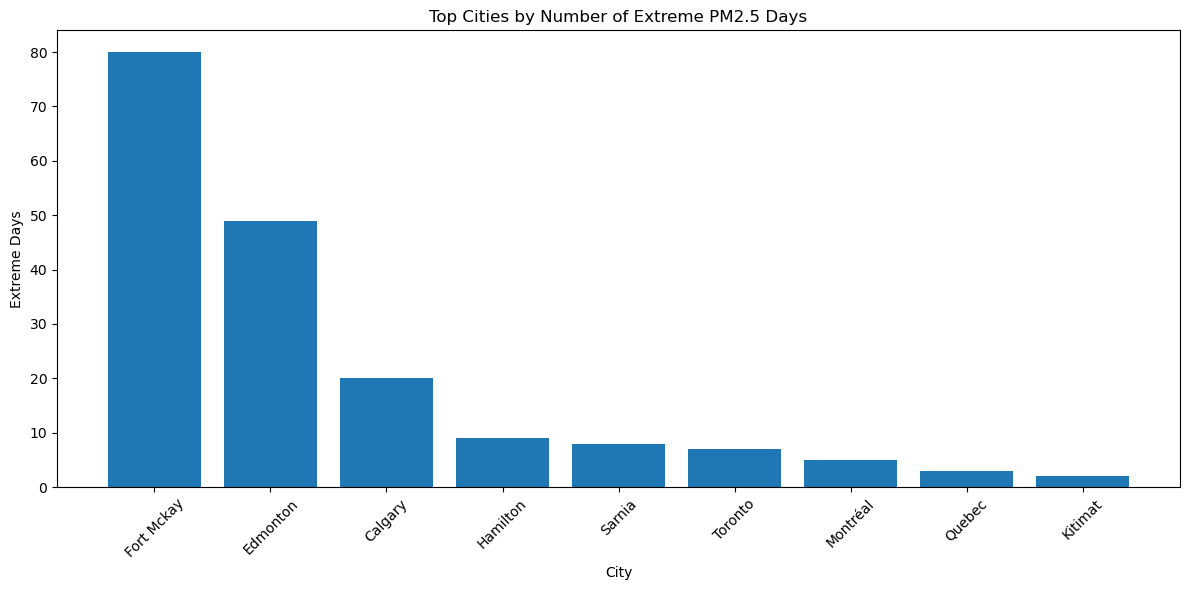

In [18]:
top10 = final_ranking.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10["City"], top10["Extreme_Days_extreme"])
plt.title("Top Cities by Number of Extreme PM2.5 Days")
plt.xlabel("City")
plt.ylabel("Extreme Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 # Interpretation
Certain industrial or wildfire-prone regions experience disproportionately higher pollution shocks, increasing public health risk.

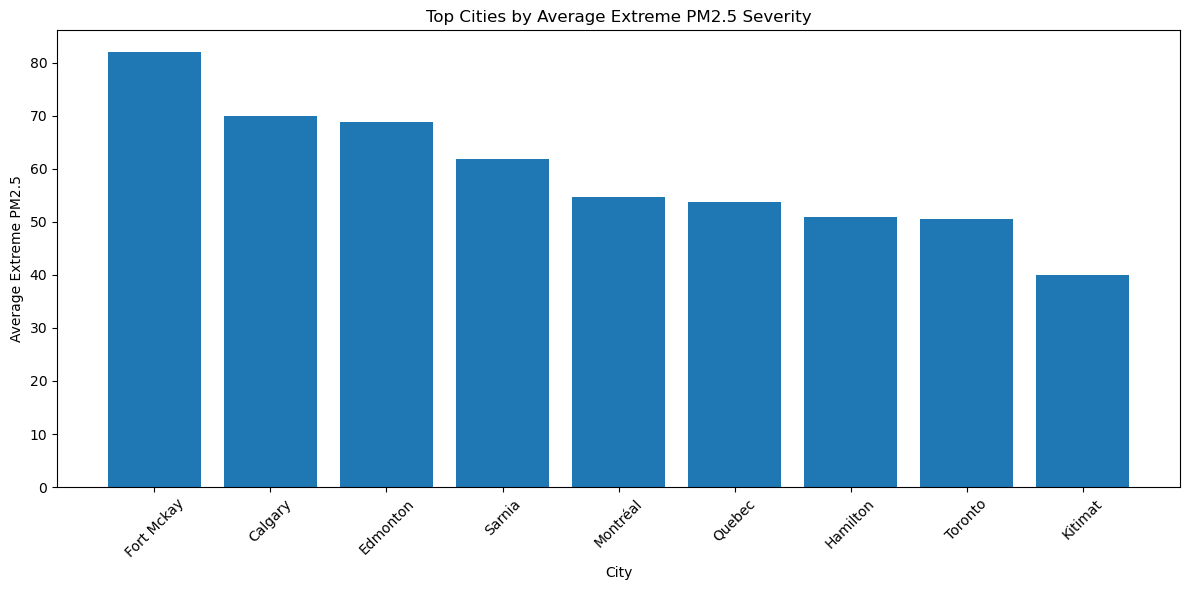

In [20]:
top10_severity = final_ranking.sort_values("Avg_Extreme_PM25", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_severity["City"], top10_severity["Avg_Extreme_PM25"])
plt.title("Top Cities by Average Extreme PM2.5 Severity")
plt.xlabel("City")
plt.ylabel("Average Extreme PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

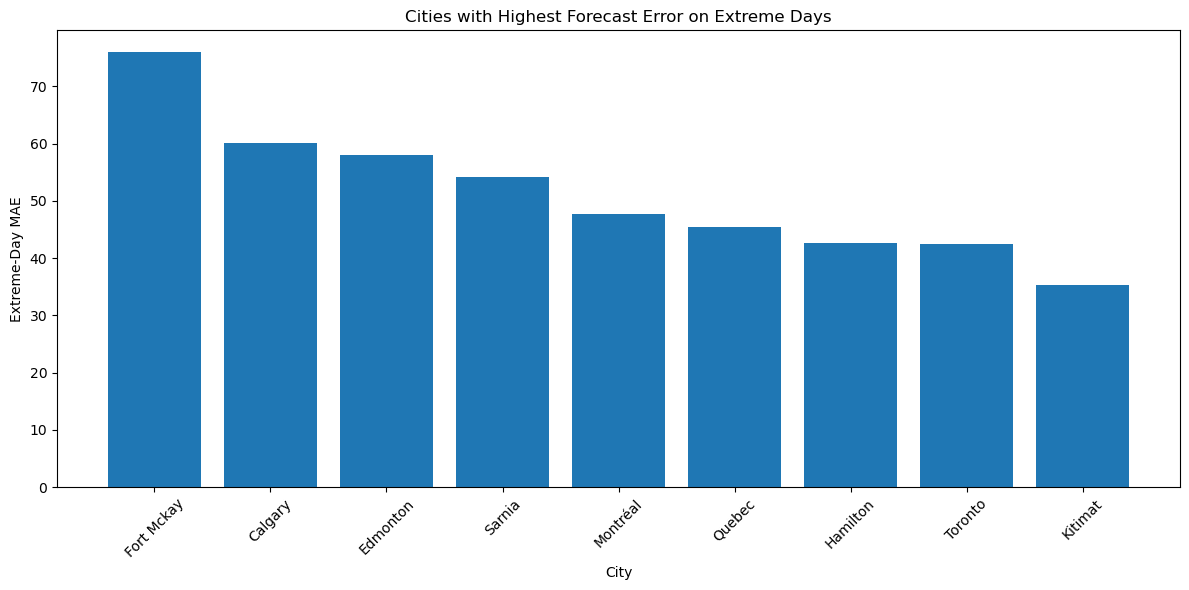

In [22]:
top10_error = final_ranking.sort_values("Extreme_Day_MAE", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_error["City"], top10_error["Extreme_Day_MAE"])
plt.title("Cities with Highest Forecast Error on Extreme Days")
plt.xlabel("City")
plt.ylabel("Extreme-Day MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
final_ranking.to_csv("../results/PM25_city_extreme_event_ranking.csv", index=False)
print("Saved: ../results/PM25_city_extreme_event_ranking.csv")

Saved: ../results/PM25_city_extreme_event_ranking.csv
